In [1]:
import random
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import skfuzzy as fuzz
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_swiss_roll
from sklearn.preprocessing import StandardScaler


from pathlib import Path


PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "components").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "components").exists():
            PROJECT_ROOT = parent
            break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from components.models import ANFISAdvanced, fcm_initialize

In [2]:
# ---------------------------
# 1) Preparing the Swiss roll data
# ---------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


def make_swiss_roll_binary(n_samples=3000, noise=0.4):
    X3d, t = make_swiss_roll(n_samples=n_samples, noise=noise, random_state=SEED)
    labels = (t > np.median(t)).astype(np.int64)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X3d).astype(np.float32)
    return X_scaled, labels


X, y = make_swiss_roll_binary()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, shuffle=True
)



In [3]:
# ---------------------------
# 5) Training loop
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

K = 2
centers_init, spreads_init = fcm_initialize(X_train, K)

s_mode_choice = "alpha_beta"
model = ANFISAdvanced(centers_init, spreads_init, s_mode=s_mode_choice).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.BCEWithLogitsLoss()

n_epochs = 1200
best_loss = float("inf")
best_state = None

for epoch in range(1, n_epochs + 1):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train_tensor)
    loss = loss_fn(logits, y_train_tensor)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
    optimizer.step()

    if loss.item() < best_loss:
        best_loss = loss.item()
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 150 == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            train_prob = torch.sigmoid(model(X_train_tensor))
            test_prob = torch.sigmoid(model(X_test_tensor))

            train_pred = (train_prob >= 0.5).float()
            test_pred = (test_prob >= 0.5).float()

            train_total = y_train_tensor.numel()
            test_total = y_test_tensor.numel()
            train_correct = int((train_pred == y_train_tensor).sum().item())
            test_correct = int((test_pred == y_test_tensor).sum().item())
            train_acc = train_correct / train_total
            test_acc = test_correct / test_total
            train_err = 1.0 - train_acc
            test_err = 1.0 - test_acc

        print(
            f"Epoch {epoch:04d}/{n_epochs}  Loss {loss.item():.4f}  "
            f"Train Acc {train_acc:.3f} (Err {train_err:.3f})  "
            f"Test Acc {test_acc:.3f} (Err {test_err:.3f})"
        )

if best_state is not None:
    model.load_state_dict(best_state)
model.eval()

with torch.no_grad():
    final_train_logits = model(X_train_tensor)
    final_test_logits = model(X_test_tensor)
    final_train_prob = torch.sigmoid(final_train_logits).cpu().numpy().reshape(-1)
    final_test_prob = torch.sigmoid(final_test_logits).cpu().numpy().reshape(-1)


def summarize_split(name, probs, labels):
    preds = (probs >= 0.5).astype(np.int64)
    total = len(labels)
    correct = int((preds == labels).sum())
    wrong = total - correct
    accuracy = correct / total
    error = wrong / total
    print(
        f"{name}: accuracy rate {accuracy:.3f} ({correct}/{total} correct points) | "
        f"error {error:.3f} ({wrong} wrong points)"
    )


print("\nFinal Results:")
print(f"Mode: {s_mode_choice}")
summarize_split("Train", final_train_prob, y_train)
summarize_split("Test", final_test_prob, y_test)



/home/nazanin/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


Epoch 0001/1200  Loss 0.7238  Train Acc 0.382 (Err 0.618)  Test Acc 0.388 (Err 0.612)
Epoch 0150/1200  Loss 0.6764  Train Acc 0.597 (Err 0.403)  Test Acc 0.600 (Err 0.400)
Epoch 0300/1200  Loss 0.6443  Train Acc 0.597 (Err 0.403)  Test Acc 0.603 (Err 0.397)
Epoch 0450/1200  Loss 0.6121  Train Acc 0.634 (Err 0.366)  Test Acc 0.655 (Err 0.345)
Epoch 0600/1200  Loss 0.5360  Train Acc 0.790 (Err 0.210)  Test Acc 0.817 (Err 0.183)
Epoch 0750/1200  Loss 0.4347  Train Acc 0.933 (Err 0.067)  Test Acc 0.938 (Err 0.062)
Epoch 0900/1200  Loss 0.3511  Train Acc 0.956 (Err 0.044)  Test Acc 0.963 (Err 0.037)
Epoch 1050/1200  Loss 0.2866  Train Acc 0.970 (Err 0.030)  Test Acc 0.973 (Err 0.027)
Epoch 1200/1200  Loss 0.2418  Train Acc 0.978 (Err 0.022)  Test Acc 0.982 (Err 0.018)

Final Results:
Mode: alpha_beta
Train: accuracy rate 0.978 (2348/2400 correct points) | error 0.022 (52 wrong points)
Test: accuracy rate 0.982 (589/600 correct points) | error 0.018 (11 wrong points)


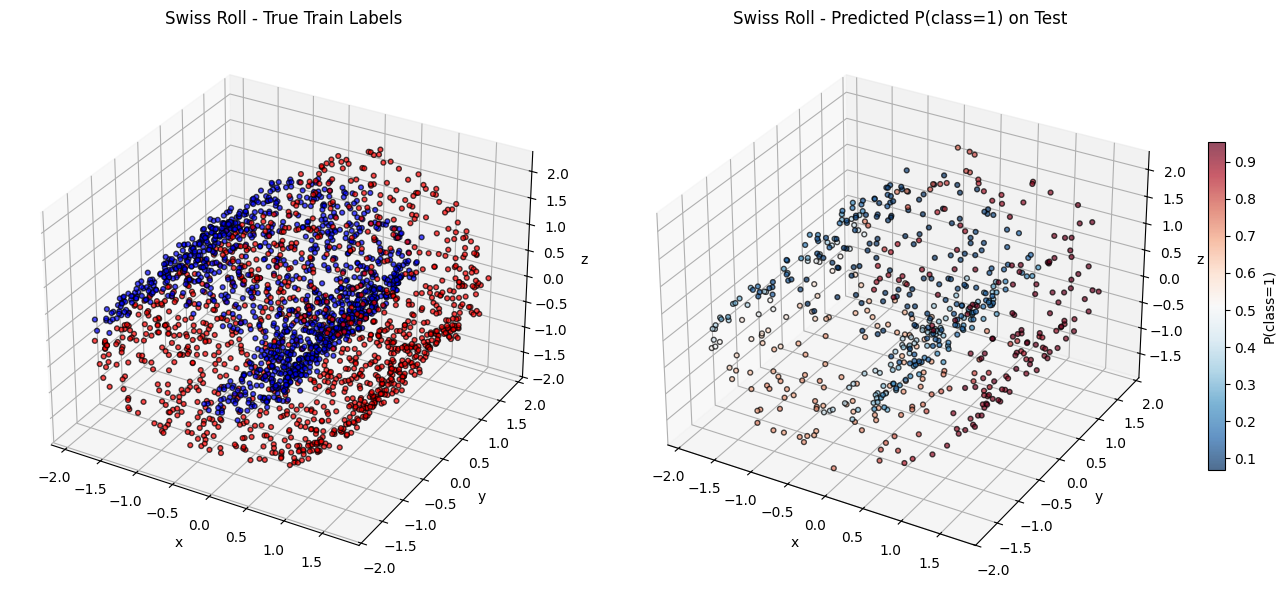

In [4]:
# ---------------------------
# 6) Visualization in 3D
# ---------------------------
with torch.no_grad():
    prob_train_vis = torch.sigmoid(model(X_train_tensor)).cpu().numpy().reshape(-1)
    prob_test_vis = torch.sigmoid(model(X_test_tensor)).cpu().numpy().reshape(-1)

fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.scatter(
    X_train[:, 0],
    X_train[:, 1],
    X_train[:, 2],
    c=y_train,
    cmap="bwr",
    s=12,
    edgecolor="k",
    alpha=0.7,
)
ax1.set_title("Swiss Roll - True Train Labels")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
scatter = ax2.scatter(
    X_test[:, 0],
    X_test[:, 1],
    X_test[:, 2],
    c=prob_test_vis,
    cmap="RdBu_r",
    s=12,
    edgecolor="k",
    alpha=0.7,
)
ax2.set_title("Swiss Roll - Predicted P(class=1) on Test")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("z")
fig.colorbar(scatter, ax=ax2, shrink=0.6, label="P(class=1)")
plt.tight_layout()
plt.show()

